# Q1 MAP prototype notebook

Interactive version of `run_q1_map.py` to make it easier to tweak scenarios and inspect outputs.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Ensure local Q1 modules are importable
cwd = Path.cwd()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

from sim import (
    DistanceTier,
    Q1Config,
    apply_distance_tier,
    build_discovery_loglike,
    build_enterprise_pta,
    draw_cw_population,
    draw_noise_params,
    inject_cw_params,
    load_discovery_pulsars,
    load_enterprise_pulsars,
    make_rng,
    set_toaerrs,
    simulate_enterprise_residuals,
)
from optimize import make_logposterior, run_map_gradient_ascent, run_svi_map

import numpy as np

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


## Configuration

Adjust these values and re-run the next cell to try different scenarios.

In [2]:
# Noise scenario: 'A' (WN), 'B' (WN+RN), 'C' (WN+RN+GWB)
scenario = "A"

# Distance tier: sigma multiplier (1.0 = real, >1 loosen, <1 tighten, 0 ~ exact)
tier_scale = 1.0
tier_name = "real"

# Ring / CW settings
n_pulsars = 10
n_cw_sources = 1
seed = 123

# Optimiser settings
opt_mode = "svi"  # "svi" (NumPyro AutoDelta) or "map" (simple gradient ascent)
steps = 100
learning_rate = 5e-3


## Run MAP pipeline

This mirrors the CLI script: draw CW/noise, simulate a dataset with enterprise, mirror it into discovery, and run a JAX MAP ascent.

In [3]:
cfg = Q1Config(
    scenario=scenario,
    distance_tier=DistanceTier(tier_name, tier_scale),
    seed=seed,
    n_pulsars=n_pulsars,
    n_cw_sources=n_cw_sources,
)

rng = make_rng(cfg.seed)
cw_draws = draw_cw_population(cfg, rng)

# Enterprise side: build PTA, apply distance tiering, simulate residuals
e_psrs = load_enterprise_pulsars(cfg)
set_toaerrs(e_psrs, sigma=1e-6)
true_distances = apply_distance_tier(e_psrs, cfg.distance_tier)
pta, ring_vecs = build_enterprise_pta(e_psrs, cfg, cw_draws)
pta.set_default_params({})

base_params = draw_noise_params(pta, cfg, rng, psrs=e_psrs)
inj_params = inject_cw_params(base_params, cw_draws, cfg)

sim_resids = simulate_enterprise_residuals(pta, inj_params, sparse_cholesky=True)
name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}



FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

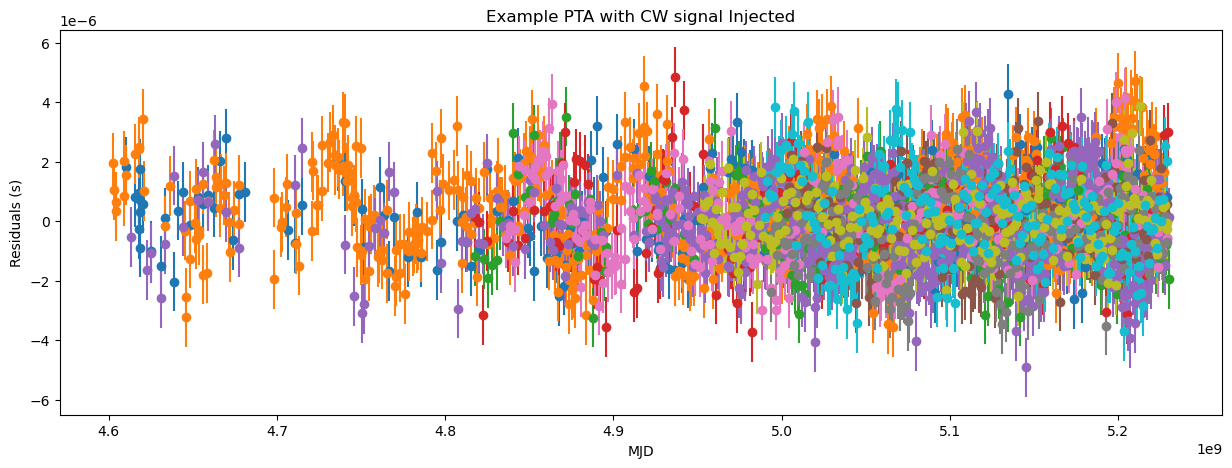

In [4]:
# Check Enterprise simulated residuals
plt.figure(figsize=(15,5))
for i, res_i in enumerate(sim_resids):
    plt.errorbar(e_psrs[i].toas, res_i, yerr=e_psrs[i].toaerrs, fmt='o')
    plt.xlabel('MJD')   
    plt.ylabel('Residuals (s)')
    plt.title("Example PTA with CW signal Injected")

In [5]:

# Discovery side: build log-likelihood with the simulated residuals
d_psrs = load_discovery_pulsars(cfg)
residual_map = {psr.name: name_to_resid[psr.name] for psr in d_psrs}
logl, param_keys = build_discovery_loglike(d_psrs, cw_draws, cfg, ring_vecs=ring_vecs, residual_map=residual_map)
logpost = make_logposterior(logl)


W1203 13:25:50.142988  315809 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1203 13:25:50.144010  315584 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


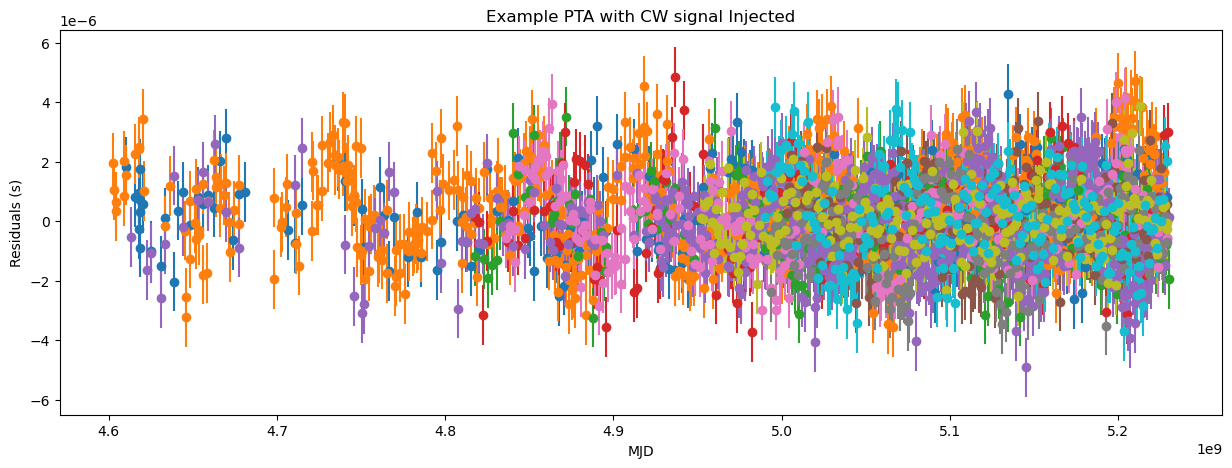

In [6]:
plt.figure(figsize=(15,5))
for i, res_i in enumerate(sim_resids):
    plt.errorbar(d_psrs[i].toas, d_psrs[i].residuals, yerr=d_psrs[i].toaerrs, fmt='o')
    plt.xlabel('MJD')   
    plt.ylabel('Residuals (s)')
    plt.title("Example PTA with CW signal Injected")

In [7]:




# Initialise from injected parameters (fallback to zero if missing)
init_params = {k: inj_params.get(k, 0.0) for k in param_keys}

if opt_mode == "svi":
    result = run_svi_map(
        logpost,
        param_keys,
        init_params,
        batch_size=500,
        max_batches=20,
        patience=3,
        peak_lr=1e-2,
        rng_seed=seed,
    )
else:
    result = run_map_gradient_ascent(
        logpost,
        param_keys,
        init_params,
        learning_rate=learning_rate,
        max_steps=steps,
    )

print(f"Finished MAP run. converged={result.converged} grad_norm={result.grad_norm:.3e}")
if result.trace:
    print(f"logpost trace (first/last): {result.trace[0]:.3f} -> {result.trace[-1]:.3f}")

# Show a small subset of parameters for quick inspection
for key in param_keys[: min(10, len(param_keys))]:
    val = result.params[key]
    inj = inj_params.get(key, None)
    delta = None if inj is None else val - inj
    if delta is None:
        print(f"{key:>24}: {val:.4f}")
    else:
        print(f"{key:>24}: {val:.4f} (inj {inj:.4f}, delta {delta:+.2e})")


RuntimeError: NumPyro + pulsar_map_noise_estimates are required for SVI MAP

: 